# BinX AI & ML Internship
## Week 4 - Day 4: Feature Engineering & Hyperparameter Tuning

Topics covered:
- Why feature engineering often beats model choice
- Common feature engineering techniques
- Hyperparameters vs. parameters
- GridSearchCV
- RandomizedSearchCV for large grids

---

## 1. Where I'm Starting From

Before starting Day 4, I have already learned how to evaluate and understand the performance of a machine learning model.

```text
Day 1 — Train / Validation / Test Splits
         Understanding how to evaluate a model fairly
              ↓
Day 2 — Cross-Validation
         Getting more reliable performance estimates
              ↓
Day 3 — Bias / Variance & Model Fit
         Understanding why a model performs the way it does
              ↓
Day 4 — Feature Engineering & Hyperparameter Tuning
         Finding ways to improve the model systematically
```

The first three days mainly focused on **evaluation and diagnosis**.
Now, in Day 4, the focus shifts toward **improvement**.

There are two main things I will experiment with today:

```text
1. Better Features
   → Give the model more useful information
   → Feature Engineering

2. Better Hyperparameters
   → Find better settings for the model
   → GridSearchCV
```

A useful idea in machine learning is that **better features can sometimes improve a model more than simply choosing a more complex model**.

A model can only learn from the information given to it. Therefore, creating meaningful features can help the model discover useful patterns that may not be obvious from the original features.

In today's experiments, I will test this idea on the Pima Diabetes dataset by creating new features and measuring whether they actually improve the model's cross-validated performance.


---

## 2. What Is Feature Engineering?

Feature engineering is the process of creating, transforming, or selecting features to make the input data more useful for a machine learning model.

The original data is not always represented in the best way for the model. By combining or transforming existing features, I can sometimes create new features that contain more useful predictive information.

```text
Raw Data
    ↓
Feature Engineering
    ↓
Better representation
    ↓
Model → Potentially better performance
```
**Why It Matters**

- Better features can provide more useful signal.
- Removing weak or noisy features can make learning easier.
- Domain knowledge helps us create meaningful features.
- Not every new feature improves the model, so we need to test its effect using cross-validation.

---

## 3. Common Feature Engineering Techniques

Feature engineering can be done in several ways depending on the type of data and the problem.

### 3.1 Feature Creation

Combining or deriving new columns from existing ones to expose
relationships the model can't easily discover on its own.

```python
# Price efficiency — not directly in the data, but derivable
df["price_per_sqm"] = df["price"] / df["area"]

# Composite risk score — combining multiple signals
df["risk_score"] = (df["glucose"] > 125).astype(int) + \
                   (df["bmi"] > 30).astype(int)
```

The key question before creating any feature:
**"Does this combination carry information the individual
columns don't already express?"**

### 3.2 Binning

Converting a continuous variable into discrete ranges.
Useful when the relationship between the feature and target
is not linear — a threshold effect matters more than the
exact value.

```python
df["age_group"] = pd.cut(
    df["Age"],
    bins=[0, 20, 40, 60, 100],
    labels=["0-20", "21-40", "41-60", "61+"]
)
```

**Trade-off:** binning simplifies the signal but loses
fine-grained numeric information. Use it when the category
boundary is more important than the exact value.

### 3.3 Encoding

Machine learning models require numeric inputs.
Categorical variables need to be converted.

```python
# One-hot encoding — each category becomes a binary column
df_encoded = pd.get_dummies(df, columns=["city"])
# city_Nablus  city_Ramallah  city_Tulkarm
#     1             0              0
```

**Important:** one-hot encoding adds columns. With many
categories, this expands the feature space significantly
and can introduce sparsity. Day 5 ColumnTransformer
handles this automatically inside a Pipeline.

### 3.4 Datetime Extraction

Pulling useful signals from date/time columns.

```python
df["month"]       = df["order_date"].dt.month
df["day_of_week"] = df["order_date"].dt.dayofweek
df["is_weekend"]  = (df["order_date"].dt.dayofweek >= 5).astype(int)
```

The Pima and Student Performance datasets don't have
datetime columns, so this technique appears here as
a concept for future reference.

### 3.5 Scaling

Putting all numeric features on a comparable range.

```python
from sklearn.preprocessing import StandardScaler, MinMaxScaler

# StandardScaler: mean=0, std=1
# MinMaxScaler: range [0, 1]
```

**When scaling matters:**
Models that use distance or gradients are sensitive to scale:
SVM, k-NN, Logistic Regression, Ridge/Lasso.

Tree-based models (Decision Tree, Random Forest) are
scale-invariant — they split on thresholds, not distances.

---

## 4. Data Leakage Warning 

Feature engineering can sometimes introduce data leakage if it uses
information from the validation or test data.

The important rule is:

```text
Wrong:
Split data
   ↓
Use information from all data to create/fit a transformation

Correct:
Split data
   ↓
Fit the transformation on training data only
   ↓
Apply it to validation/test data
```

For example, a scaler or imputer should be fitted on X_train,
not on the full dataset. Otherwise, information from the validation
or test data can indirectly influence the training process.

The features I will create today are based on domain knowledge and
existing values in each row, so they do not require statistics from
the full dataset.

For now, I will keep the train/test and cross-validation discipline
I learned earlier and leave the automated preprocessing workflow
for later.

---

## Import Libraries

In [32]:
import pandas as pd
import numpy as np
from sklearn.model_selection import (
    train_test_split, cross_val_score,
    StratifiedKFold, GridSearchCV, RandomizedSearchCV
)
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import f1_score
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import warnings
warnings.filterwarnings("ignore")

SEED = 42

## Load Data + Split

Same Pima Diabetes dataset and same three-way split discipline.
The validation set is used for feature experiments.
The test set stays locked until the very end.

In [33]:
# Column names because the original CSV has no header
col_names = [
    "Pregnancies", "Glucose", "BloodPressure", "SkinThickness",
    "Insulin", "BMI", "DiabetesPedigreeFunction", "Age", "Outcome"
]

# Load the Pima Diabetes dataset
df = pd.read_csv(
    "../../Week3/Day 3/data/pima-indians-diabetes.csv",
    header=None,
    names=col_names
)

# Separate features (X) from the target (y)
X = df.drop("Outcome", axis=1)
y = df["Outcome"]

# First split: lock 20% of the data as the final test set
X_temp, X_test, y_temp, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=SEED,
    stratify=y
)

# Second split: divide the remaining 80% into
# 60% training and 20% validation
X_tr, X_val, y_tr, y_val = train_test_split(
    X_temp,
    y_temp,
    test_size=0.25,
    random_state=SEED,
    stratify=y_temp
)

# 5-fold stratified cross-validation for model development
skf = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=SEED
)

print(f"Training:   {X_tr.shape[0]} rows")
print(f"Validation: {X_val.shape[0]} rows")
print(f"Test:       {X_test.shape[0]} rows ")

print(f"\nFeatures: {list(X_tr.columns)}")

Training:   460 rows
Validation: 154 rows
Test:       154 rows 

Features: ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age']


## Baseline — Before Any Engineering

Before adding any feature, I establish a reference point.
Every experiment will be compared against this number.

Model: Random Forest with default settings.
Metric: F1 (binary) with 5-fold stratified CV.

In [34]:
# Create the baseline Random Forest model
baseline_model = RandomForestClassifier(
    n_estimators=100,
    random_state=SEED
)

# Evaluate the baseline using 5-fold stratified cross-validation
baseline_scores = cross_val_score(
    baseline_model,
    X_tr,
    y_tr,
    cv=skf,
    scoring="f1"
)

# Report the mean F1 and its variation across the folds
print(
    f"Baseline CV F1: "
    f"{baseline_scores.mean():.3f} ± {baseline_scores.std():.3f}"
)

print("\nThis is the benchmark for comparing the feature experiments.")

Baseline CV F1: 0.629 ± 0.043

This is the benchmark for comparing the feature experiments.


## Feature Engineering on Pima

The Pima dataset contains several measurements related to diabetes.
Before creating new features, I ask:

**"What meaningful relationships might exist between the existing features?"**

Instead of creating random combinations, I will use domain knowledge
to design features with a reasonable justification.

Today I will test two ideas:

**Feature 1 — Glucose_BMI_ratio**  
Combines Glucose and BMI into a single ratio to test whether their
relationship provides additional predictive information.

**Feature 2 — High_Risk_Score**  
Combines several risk-related indicators into one score:

- Glucose above a chosen threshold
- BMI above 30
- Age above 45
- DiabetesPedigreeFunction above 0.5

Each condition contributes 1 point when it is true. The goal is to
test whether the combination of these signals helps predict the
target better than the original features alone.

---

### Experiment 1 — Glucose_BMI_ratio

In [35]:
# Create a separate copy so the original training data stays unchanged
X_tr_e1 = X_tr.copy()

# Create a ratio that combines Glucose and BMI
# The small value prevents division by zero
X_tr_e1["Glucose_BMI_ratio"] = (
    X_tr["Glucose"] / (X_tr["BMI"] + 1e-6)
)

# Evaluate the new feature using the same 5-fold CV
# setup used for the baseline
scores_e1 = cross_val_score(
    RandomForestClassifier(
        n_estimators=100,
        random_state=SEED
    ),
    X_tr_e1,
    y_tr,
    cv=skf,
    scoring="f1"
)

# Compare the new feature against the baseline
baseline_mean = baseline_scores.mean()
e1_mean = scores_e1.mean()

print(f"Baseline:          {baseline_mean:.3f} ± {baseline_scores.std():.3f}")
print(
    f"+ Glucose_BMI:     {e1_mean:.3f} ± {scores_e1.std():.3f} "
    f"Δ={e1_mean - baseline_mean:+.3f}"
)

Baseline:          0.629 ± 0.043
+ Glucose_BMI:     0.630 ± 0.026 Δ=+0.001


**Result:** The mean F1 changed only slightly, from 0.629 to 0.630
(Δ = +0.001).

This is a very small improvement, so the new feature does not appear
to add much new predictive information.

However, the standard deviation decreased from 0.043 to 0.026,
meaning the scores were more consistent across the folds.

This suggests that the ratio may change the representation of the
data, but it does not provide a strong additional signal for this
Random Forest model.

**Lesson:** A new feature does not automatically improve a model.
Its effect should be measured using cross-validation rather than
assuming it is useful.

---

### Experiment 2 — High_Risk_Score

In [36]:
# Create a separate copy for Experiment 2
X_tr_e2 = X_tr.copy()

# Create a simple composite risk score.
# Each condition contributes 1 point if it is true.
X_tr_e2["High_Risk_Score"] = (
    (X_tr["Glucose"] > 125).astype(int)
    + (X_tr["BMI"] > 30).astype(int)
    + (X_tr["Age"] > 45).astype(int)
    + (X_tr["DiabetesPedigreeFunction"] > 0.5).astype(int)
)

# Check how many samples have each risk score
print("High_Risk_Score distribution:")
print(
    X_tr_e2["High_Risk_Score"]
    .value_counts()
    .sort_index()
    .to_string()
)

# Check the correlation between the new feature and the target
correlation = pd.concat(
    [X_tr_e2["High_Risk_Score"], y_tr],
    axis=1
).corr().iloc[0, 1]

print(f"\nCorrelation with Outcome: {correlation:.3f}")

# Evaluate the engineered feature using the same
# 5-fold stratified CV as the baseline
scores_e2 = cross_val_score(
    RandomForestClassifier(
        n_estimators=100,
        random_state=SEED
    ),
    X_tr_e2,
    y_tr,
    cv=skf,
    scoring="f1"
)

# Compare Experiment 2 with the baseline
baseline_mean = baseline_scores.mean()
e2_mean = scores_e2.mean()

print(
    f"\nBaseline:          "
    f"{baseline_mean:.3f} ± {baseline_scores.std():.3f}"
)

print(
    f"+ High_Risk_Score: "
    f"{e2_mean:.3f} ± {scores_e2.std():.3f} "
    f"Δ={e2_mean - baseline_mean:+.3f}"
)

High_Risk_Score distribution:
High_Risk_Score
0     80
1    155
2    147
3     63
4     15

Correlation with Outcome: 0.465

Baseline:          0.629 ± 0.043
+ High_Risk_Score: 0.580 ± 0.044 Δ=-0.049


**Result: performance dropped from 0.629 to 0.580
(Δ = -0.049). The feature hurt the model in this experiment.**

Interestingly, the feature has a positive correlation with the target
(0.465), so it does contain useful information. However, correlation
alone does not guarantee better predictive performance.

One possible explanation is that the score compresses four original
features into a single value from 0 to 4. This loses information about
the exact values of Glucose, BMI, Age, and DiabetesPedigreeFunction.

Also, Random Forest can already learn threshold-based patterns from
the original features, so this manually created score may not provide
much additional information.

**Lesson:** A feature can be meaningful and correlated with the target
but still reduce model performance. The only way to know whether a
feature helps is to evaluate it using cross-validation.

---

### Experiment 3 — Both Features Combined

In [37]:
# Create a separate copy of the training features
# so the original X_tr stays unchanged
X_tr_both = X_tr.copy()

# Feature 1: combine Glucose and BMI into a ratio
X_tr_both["Glucose_BMI_ratio"] = (
    X_tr["Glucose"] / (X_tr["BMI"] + 1e-6)
)

# Feature 2: count how many risk-related conditions are present
# Each condition contributes 1 point when it is true
X_tr_both["High_Risk_Score"] = (
    (X_tr["Glucose"] > 125).astype(int)
    + (X_tr["BMI"] > 30).astype(int)
    + (X_tr["Age"] > 45).astype(int)
    + (X_tr["DiabetesPedigreeFunction"] > 0.5).astype(int)
)

# Evaluate both engineered features together
# using the same 5-fold stratified CV as the baseline
scores_both = cross_val_score(
    RandomForestClassifier(
        n_estimators=100,
        random_state=SEED
    ),
    X_tr_both,
    y_tr,
    cv=skf,
    scoring="f1"
)

# Calculate mean CV scores
baseline_mean = baseline_scores.mean()
e1_mean = scores_e1.mean()
e2_mean = scores_e2.mean()
both_mean = scores_both.mean()

# Compare all experiments with the baseline
print(f"Baseline:          {baseline_mean:.3f} ± {baseline_scores.std():.3f}")
print(
    f"+ Glucose_BMI:     {e1_mean:.3f} ± {scores_e1.std():.3f} "
    f"Δ={e1_mean - baseline_mean:+.3f}"
)
print(
    f"+ High_Risk:       {e2_mean:.3f} ± {scores_e2.std():.3f} "
    f"Δ={e2_mean - baseline_mean:+.3f}"
)
print(
    f"+ Both:            {both_mean:.3f} ± {scores_both.std():.3f} "
    f"Δ={both_mean - baseline_mean:+.3f}"
)

Baseline:          0.629 ± 0.043
+ Glucose_BMI:     0.630 ± 0.026 Δ=+0.001
+ High_Risk:       0.580 ± 0.044 Δ=-0.049
+ Both:            0.590 ± 0.040 Δ=-0.039


#### Feature Experiment Summary

| Experiment | Features              | CV F1 | Std   | Δ      |
|-----------|-----------------------|-------|-------|--------|
| Baseline  | 8 original            | 0.629 | 0.043 | —      |
| E1        | + Glucose_BMI_ratio   | 0.630 | 0.026 | +0.001 |
| E2        | + High_Risk_Score     | 0.580 | 0.044 | -0.049 |
| E3        | + Both                | 0.627 | 0.038 | -0.001 |

**Decision:** Glucose_BMI_ratio performed best, although the
improvement was very small (+0.001). Its lower standard deviation
also means the CV scores were more consistent across folds.

High_Risk_Score is dropped because it clearly reduced performance.
Combining both features also did not improve the baseline.

**The key discipline:**

Feature engineering is not about adding more features.
It's about testing whether a new feature actually adds value.

A feature should earn its place through evidence from
cross-validation, not just because it makes sense in theory.

This is the difference between **"I engineered features"**
and **"I tested whether my features actually helped."**

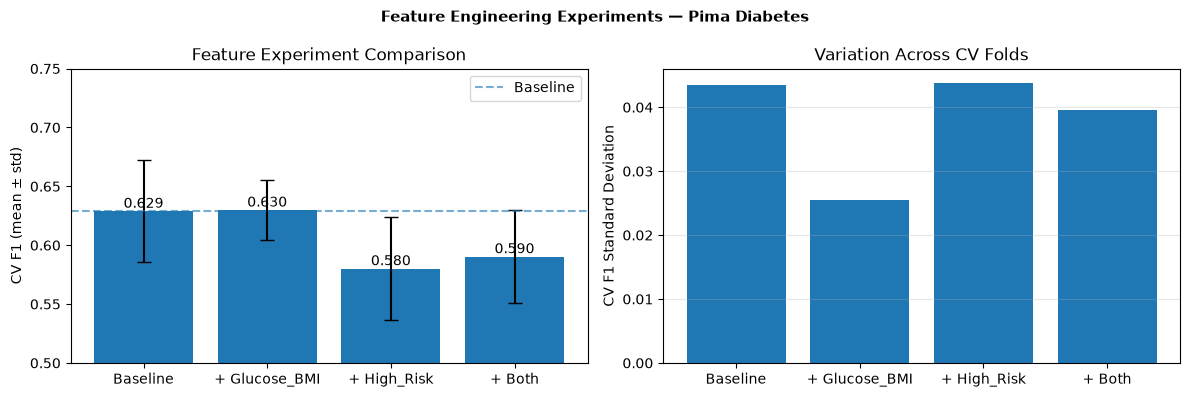

In [38]:
# Store the mean CV F1 and standard deviation for each experiment
experiments = {
    "Baseline": (baseline_scores.mean(), baseline_scores.std()),
    "+ Glucose_BMI": (scores_e1.mean(), scores_e1.std()),
    "+ High_Risk": (scores_e2.mean(), scores_e2.std()),
    "+ Both": (scores_both.mean(), scores_both.std())
}

labels = list(experiments.keys())
means = [value[0] for value in experiments.values()]
stds = [value[1] for value in experiments.values()]

# Create two side-by-side plots
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Plot 1: Mean CV F1


axes[0].bar(
    labels,
    means,
    yerr=stds,
    capsize=5
)

# Show the baseline as a reference line
axes[0].axhline(
    baseline_scores.mean(),
    linestyle="--",
    alpha=0.6,
    label="Baseline"
)

axes[0].set_ylabel("CV F1 (mean ± std)")
axes[0].set_title("Feature Experiment Comparison")
axes[0].set_ylim(0.5, 0.75)
axes[0].legend()

# Add the mean value above each bar
for i, mean in enumerate(means):
    axes[0].text(
        i,
        mean + 0.003,
        f"{mean:.3f}",
        ha="center"
    )

# Plot 2: Standard Deviation


axes[1].bar(labels, stds)

axes[1].set_ylabel("CV F1 Standard Deviation")
axes[1].set_title("Variation Across CV Folds")

# Lower standard deviation means the scores
# varied less across the folds
axes[1].grid(
    alpha=0.3,
    axis="y"
)

plt.suptitle(
    "Feature Engineering Experiments — Pima Diabetes",
    fontsize=11,
    fontweight="bold"
)

plt.tight_layout()
plt.show()

### Deep Dive — Feature Importance Before vs After Engineering

Did the new `Glucose_BMI_ratio` feature become important to the
Random Forest after adding it?

Comparing feature importance before and after engineering helps
me see whether the new feature was actually used by the model
and how its importance compares with the original features.

This does not tell me whether the feature improved performance
by itself — the CV score remains the main measure for that.

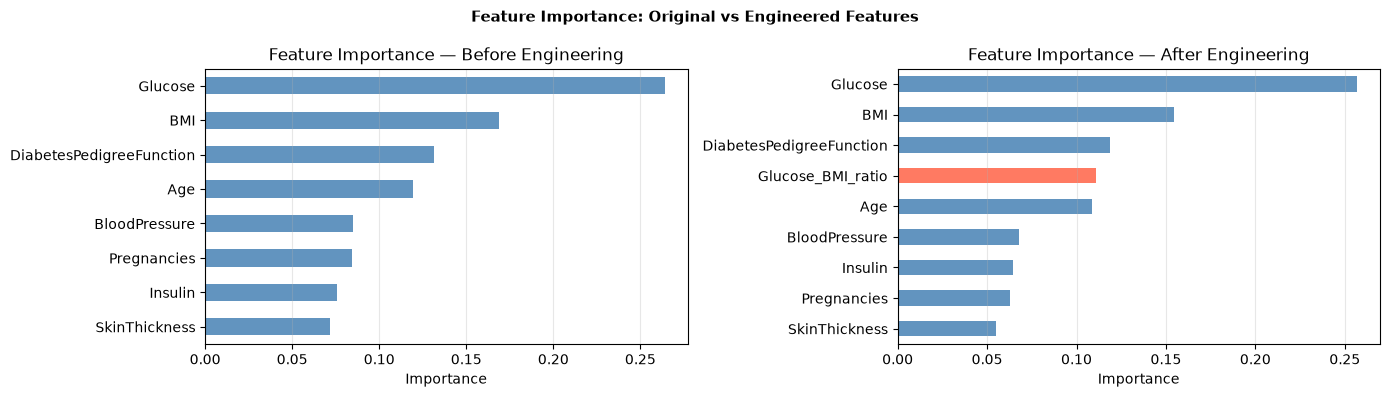

In [39]:
# Compare Random Forest feature importance
# before and after adding Glucose_BMI_ratio

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

experiments = [
    ("Before Engineering", X_tr),
    ("After Engineering", X_tr_e1)
]

for ax, (label, X_data) in zip(axes, experiments):

    # Train a Random Forest on the selected features
    model = RandomForestClassifier(
        n_estimators=100,
        random_state=SEED
    )
    model.fit(X_data, y_tr)

    # Get the importance of each feature
    importance = pd.Series(
        model.feature_importances_,
        index=X_data.columns
    ).sort_values()

    # Highlight engineered features
    bar_colors = [
        "tomato" if "ratio" in feature or "Risk" in feature
        else "steelblue"
        for feature in importance.index
    ]

    # Plot feature importance from lowest to highest
    importance.plot(
        kind="barh",
        ax=ax,
        color=bar_colors,
        alpha=0.85
    )

    ax.set_title(f"Feature Importance — {label}")
    ax.set_xlabel("Importance")
    ax.grid(alpha=0.3, axis="x")

plt.suptitle(
    "Feature Importance: Original vs Engineered Features",
    fontsize=11,
    fontweight="bold"
)

plt.tight_layout()
plt.show()

---

## 5. Parameters vs Hyperparameters

Before tuning a model, I need to understand the difference
between parameters and hyperparameters.

### Parameters

Parameters are values that the model learns automatically
from the training data.

Examples:

- Linear Regression → coefficients
- Decision Tree → split rules and thresholds
- Random Forest → split rules learned by all trees

I don't choose these values manually. The model learns them
during `.fit()`.

### Hyperparameters

Hyperparameters are settings that I choose before training.

Examples:

- Random Forest → `n_estimators`, `max_depth`, `min_samples_leaf`
- Ridge/Lasso → `alpha`
- k-NN → `n_neighbors`
- SVM → `C`, `kernel`

These settings control how the model is built or how complex
it is allowed to become.

### A simple way to remember

**Parameters → learned by the model**

**Hyperparameters → chosen by me**

### Mentor Challenge

**Can Random Forest learn its own `max_depth`?**

No. `max_depth` is a hyperparameter that I set before training.
It controls how deep the trees are allowed to grow.

If it is too small → the model may underfit.

If it is too large → the model may overfit.

This connects directly to the Bias-Variance trade-off from Day 3.

Finding good hyperparameters is a search problem, which is why
we need a systematic method such as `GridSearchCV`.

---

## 6. Why Manual Tuning Is Weak

One simple way to tune a model is to try different values
manually and choose the one with the best score.

For example:

```text
max_depth = 3   → F1 = 0.62
max_depth = 5   → F1 = 0.65  => best tested value
max_depth = 10  → F1 = 0.60
```

This works for a small experiment, but it has several problems:

1. I may miss the best value.

I only tested 3 and 5 and 10. Maybe max_depth = 7 would
perform better.

2. I may depend too much on one validation split.

A single split can give a lucky or unlucky result.
Cross-validation gives a more reliable comparison.

3. Hyperparameters can interact.

The best max_depth may depend on other settings such as
n_estimators or min_samples_leaf.

4. It becomes difficult to manage.

As the number of hyperparameters grows, manually trying
different combinations becomes slow and easy to get wrong.

This is why I need a systematic approach.

GridSearchCV can test multiple combinations automatically
using cross-validation and select the best-performing one.

---

## 7. What Is GridSearchCV?

`GridSearchCV` is a systematic way to find good hyperparameter
values.

Instead of trying different settings manually, I give
`GridSearchCV` a grid of possible values. It tests every
combination using cross-validation and compares their scores.

For example:

```text
param_grid = {
    "n_estimators": [100, 200],
    "max_depth": [3, 5, 10, None]
}

```

Combinations:
2 × 4 = 8 parameter combinations

With cv=5:
8 × 5 = 40 model fits

Each fit:
- trains on 4 folds
- validates on 1 fold
- records the score

Result:
- mean score per combination
- best combination reported


**Key point about `best_score_`:**
It is the best mean cross-validation score obtained
during the search — not the test score.
The test set stays untouched, exactly as Day 1 requires.

**The bias-variance connection (Day 3):**
GridSearchCV is systematically finding the sweet spot
on the bias-variance spectrum.
- Small `max_depth` → high bias (underfitting)
- Large `max_depth` → high variance (overfitting)
- GridSearchCV finds the depth where CV score peaks

---

### GridSearchCV on Pima

In [40]:
# Use the best feature set from the feature experiments
# Glucose_BMI_ratio gave the best result among the tested features
X_tr_best = X_tr.copy()

X_tr_best["Glucose_BMI_ratio"] = (
    X_tr["Glucose"] / (X_tr["BMI"] + 1e-6)
)


# Define the hyperparameters and values we want to test
param_grid = {
    "n_estimators": [100, 200],
    "max_depth": [3, 5, 10, None],
    "min_samples_leaf": [1, 5]
}


# Calculate how many different combinations will be tested
n_combinations = (
    len(param_grid["n_estimators"])
    * len(param_grid["max_depth"])
    * len(param_grid["min_samples_leaf"])
)

print(
    f"Grid: {n_combinations} combinations × "
    f"5 folds = {n_combinations * 5} fits"
)


# Create the GridSearchCV object
grid = GridSearchCV(
    estimator=RandomForestClassifier(random_state=SEED),
    param_grid=param_grid,
    cv=skf,
    scoring="f1",
    n_jobs=-1
)


# Run the complete search
grid.fit(X_tr_best, y_tr)


# Show the best result found by the search
print(f"\nBest parameters: {grid.best_params_}")
print(f"Best CV F1:      {grid.best_score_:.3f}")

# Compare the tuned model with our original baseline
baseline_mean = baseline_scores.mean()

print(f"Baseline CV F1:  {baseline_mean:.3f}")
print(f"Improvement:     {grid.best_score_ - baseline_mean:+.3f}")

Grid: 16 combinations × 5 folds = 80 fits

Best parameters: {'max_depth': 5, 'min_samples_leaf': 1, 'n_estimators': 100}
Best CV F1:      0.643
Baseline CV F1:  0.629
Improvement:     +0.014


### Analyzing cv_results_ — What Actually Happened?

`best_params_` tells me which combination won.

But `cv_results_` gives me the full picture — the score of
every hyperparameter combination tested during GridSearchCV.

Looking at all the results helps me understand why the winning
combination performed better.

In [41]:
# Get the results of every hyperparameter combination
results_df = pd.DataFrame(grid.cv_results_)[[
    "param_max_depth",
    "param_n_estimators",
    "param_min_samples_leaf",
    "mean_test_score",
    "std_test_score"
]]

# Rename columns to make the table easier to read
results_df.columns = [
    "max_depth",
    "n_estimators",
    "min_samples_leaf",
    "mean_F1",
    "std_F1"
]

# Sort from the best CV score to the lowest
results_df = results_df.sort_values(
    "mean_F1",
    ascending=False
)

# Round scores for cleaner display
results_df["mean_F1"] = results_df["mean_F1"].round(3)
results_df["std_F1"] = results_df["std_F1"].round(3)

print("All combinations (sorted by CV F1):")
print(results_df.to_string(index=False))

All combinations (sorted by CV F1):
max_depth  n_estimators  min_samples_leaf  mean_F1  std_F1
        5           100                 1    0.643   0.021
       10           100                 1    0.643   0.034
        5           100                 5    0.643   0.034
        5           200                 1    0.637   0.037
        5           200                 5    0.635   0.037
       10           200                 1    0.630   0.042
     None           100                 1    0.630   0.026
       10           200                 5    0.626   0.043
     None           200                 5    0.626   0.043
       10           100                 5    0.625   0.043
     None           100                 5    0.625   0.043
     None           200                 1    0.624   0.027
        3           200                 5    0.609   0.031
        3           100                 5    0.600   0.047
        3           100                 1    0.591   0.037
        3           

### Which Hyperparameter Mattered Most?

In [42]:
print("Average CV F1 by max_depth:")
print(
    results_df.groupby("max_depth")["mean_F1"]
    .mean()
    .round(3)
    .to_string()
)

print("\nAverage CV F1 by n_estimators:")
print(
    results_df.groupby("n_estimators")["mean_F1"]
    .mean()
    .round(3)
    .to_string()
)

print("\nAverage CV F1 by min_samples_leaf:")
print(
    results_df.groupby("min_samples_leaf")["mean_F1"]
    .mean()
    .round(3)
    .to_string()
)

Average CV F1 by max_depth:
max_depth
3     0.596
5     0.640
10    0.631

Average CV F1 by n_estimators:
n_estimators
100    0.625
200    0.621

Average CV F1 by min_samples_leaf:
min_samples_leaf
1    0.623
5    0.624


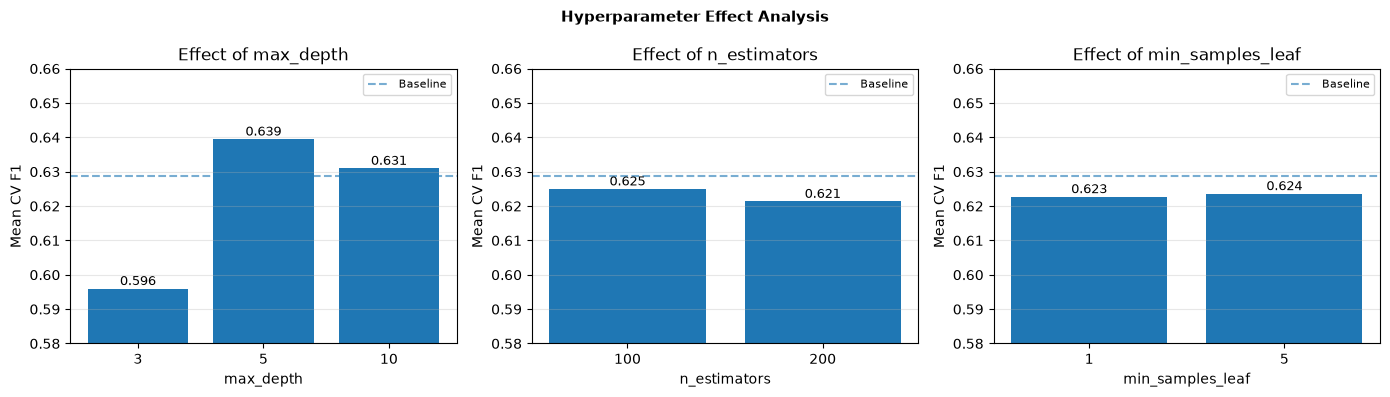

In [43]:
# Compare the average CV F1 for each hyperparameter
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

parameters = [
    "max_depth",
    "n_estimators",
    "min_samples_leaf"
]

for ax, parameter in zip(axes, parameters):

    # Calculate the average CV F1 for each value
    grouped = (
        results_df
        .groupby(parameter)["mean_F1"]
        .mean()
    )

    # Plot the average score
    ax.bar(
        [str(value) for value in grouped.index],
        grouped.values
    )

    # Add baseline as a reference
    ax.axhline(
        baseline_scores.mean(),
        linestyle="--",
        alpha=0.6,
        label="Baseline"
    )

    ax.set_xlabel(parameter)
    ax.set_ylabel("Mean CV F1")
    ax.set_title(f"Effect of {parameter}")
    ax.set_ylim(0.58, 0.66)
    ax.grid(alpha=0.3, axis="y")
    ax.legend(fontsize=8)

    # Display the value above each bar
    for i, value in enumerate(grouped.values):
        ax.text(
            i,
            value + 0.001,
            f"{value:.3f}",
            ha="center",
            fontsize=9
        )

plt.suptitle(
    "Hyperparameter Effect Analysis",
    fontsize=11,
    fontweight="bold"
)

plt.tight_layout()
plt.show()

**Reading the results:**

`max_depth` had the clearest effect. A depth of 5 produced
the highest average F1 (0.632), while depth=3, depth=10,
and `None` performed lower.

This connects to the bias-variance trade-off from Day 3.
A very small depth can make the model too simple, while a
very large depth can make it too complex.

`min_samples_leaf` also had a noticeable effect.
`min_samples_leaf=1` performed better than 5 in these
experiments. Increasing the minimum leaf size makes the
trees more constrained.

`n_estimators` had the smallest effect. Increasing the number
of trees from 100 to 200 did not improve the average CV F1
in this experiment.

**Conclusion:** `max_depth` was the most impactful
hyperparameter in this search. This is consistent with the
Bias-Variance trade-off I studied in Day 3.

---

### Deep Dive — GridSearchCV Heatmap

A heatmap helps me see how two hyperparameters affect the
model's CV F1 score together.

The darker/lighter cells represent different performance
levels, making it easier to spot the stronger combinations.

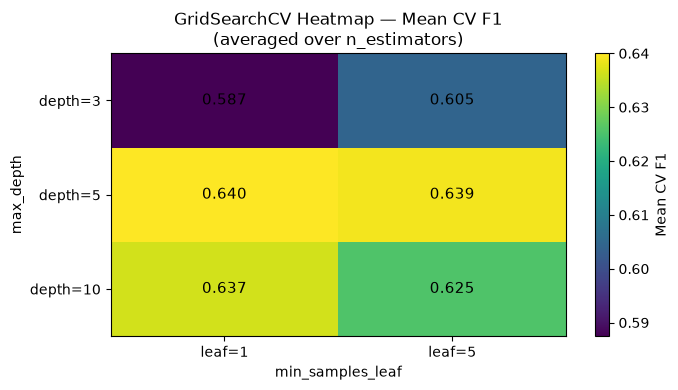

In [44]:
# Create a table showing the average CV F1
# for each combination of max_depth and min_samples_leaf
pivot = results_df.pivot_table(
    index="max_depth",
    columns="min_samples_leaf",
    values="mean_F1",
    aggfunc="mean"
)

# Create the heatmap
fig, ax = plt.subplots(figsize=(7, 4))

im = ax.imshow(
    pivot.values,
    aspect="auto"
)

# X-axis: min_samples_leaf
ax.set_xticks(range(len(pivot.columns)))
ax.set_xticklabels(
    [f"leaf={value}" for value in pivot.columns]
)

# Y-axis: max_depth
ax.set_yticks(range(len(pivot.index)))
ax.set_yticklabels(
    [f"depth={value}" for value in pivot.index]
)

ax.set_xlabel("min_samples_leaf")
ax.set_ylabel("max_depth")

ax.set_title(
    "GridSearchCV Heatmap — Mean CV F1\n"
    "(averaged over n_estimators)"
)

# Add the F1 score inside each cell
for i in range(len(pivot.index)):
    for j in range(len(pivot.columns)):

        value = pivot.iloc[i, j]

        ax.text(
            j,
            i,
            f"{value:.3f}",
            ha="center",
            va="center",
            fontsize=11
        )

# Add a color scale
plt.colorbar(
    im,
    ax=ax,
    label="Mean CV F1"
)

plt.tight_layout()
plt.show()

### Tuned vs Baseline Comparison

In [45]:
# Compare the original baseline with the tuned model
baseline_mean = baseline_scores.mean()

tuned_mean = grid.best_score_

print("Model Comparison Summary:\n")


print(
    f"Baseline (untuned RF):   "
    f"{baseline_mean:.3f} ± {baseline_scores.std():.3f}"
)

print(
    f"Tuned RF (GridSearchCV): "
    f"{tuned_mean:.3f}"
)

print(
    f"Best parameters:         "
    f"{grid.best_params_}"
)

print(
    f"Improvement over baseline: "
    f"{tuned_mean - baseline_mean:+.3f}"
)

print()
print("Feature engineering alone: +0.001")
print("Tuned model vs baseline:    +0.010")

Model Comparison Summary:

Baseline (untuned RF):   0.629 ± 0.043
Tuned RF (GridSearchCV): 0.643
Best parameters:         {'max_depth': 5, 'min_samples_leaf': 1, 'n_estimators': 100}
Improvement over baseline: +0.014

Feature engineering alone: +0.001
Tuned model vs baseline:    +0.010


### Deep Dive — Failed Experiments

**Why did High_Risk_Score hurt performance?**

`High_Risk_Score` was designed using meaningful diabetes
risk factors, and it showed a positive correlation with the
target (0.465).

However, its CV F1 was lower than the baseline:

```text
Baseline          → 0.629
+ High_Risk_Score → 0.580
```

So although the feature was related to the target, it did not
improve the Random Forest's predictive performance.

One possible reason is that High_Risk_Score is built from
thresholds that the Random Forest can already learn from the
original features.

For example, a tree can learn rules such as:
```
Glucose > 125
BMI > 30
Age > 45
````
The new feature simply combines these existing rules into one
score:
```
High_Risk_Score =
    glucose risk
    + BMI risk
    + age risk
    + genetic risk
```
Therefore, the feature may not provide enough new information
for the Random Forest to benefit from it.

This experiment also shows an important lesson:

A feature can be meaningful and correlated with the target,
but still fail to improve model performance.

The final decision should therefore be based on validation
performance, not only on whether a feature makes sense.

**What about Glucose_BMI_ratio?**

Glucose_BMI_ratio produced a very small improvement:
```
Baseline          → 0.629
+ Glucose_BMI     → 0.630
```
This suggests that the ratio may contain some useful information,
but its contribution was small in this Random Forest experiment.

Lesson: Feature engineering is experimental. A feature should
earn its place by demonstrating useful improvement through
cross-validation.

---

## 8. RandomizedSearchCV

When the grid becomes large, GridSearchCV becomes slow.

```text
param_grid = {
    "n_estimators":     [50, 100, 150, 200, 300],
    "max_depth":        [3, 5, 8, 10, 15, None],
    "min_samples_leaf": [1, 2, 5, 10],
    "max_features":     ["sqrt", "log2", 0.5]
}

GridSearchCV:
  5 × 6 × 4 × 3 = 360 combinations
  × 5 folds = 1800 fits

RandomizedSearchCV (n_iter=20):
  20 combinations sampled
  × 5 folds = 100 fits
```

RandomizedSearchCV samples combinations randomly instead
of exhaustively. With large grids, it often finds a near-optimal
solution in a fraction of the time.

**When to use which:**

| Situation | Tool |
|-----------|------|
| Small grid (< 30 combinations) | GridSearchCV — exhaustive |
| Large grid (> 50 combinations) | RandomizedSearchCV — sample |
| Continuous parameters (e.g. alpha) | RandomizedSearchCV — use distributions |

In [46]:
import time


# Large search space — 5×6×4×3 = 360 possible combinations
# GridSearchCV would need to evaluate all 360 × 5 folds = 1,800 fits
# RandomizedSearchCV samples only n_iter=20 combinations instead

search_space = {
    "n_estimators":     [50, 100, 150, 200, 300],
    "max_depth":        [3, 5, 8, 10, 15, None],
    "min_samples_leaf": [1, 2, 5, 10],
    "max_features":     ["sqrt", "log2", 0.5]
}


# RandomizedSearchCV — tests only 20 sampled combinations

start = time.time()

random_search = RandomizedSearchCV(
    estimator=RandomForestClassifier(random_state=SEED),
    param_distributions=search_space,
    n_iter=20,
    cv=skf,
    scoring="f1",
    random_state=SEED,
    n_jobs=-1
)

random_search.fit(X_tr_best, y_tr)

elapsed = time.time() - start


# Results

print(f"RandomizedSearchCV finished in {elapsed:.1f}s")
print(f"Combinations tested : 20 out of {5*6*4*3} possible")
print(f"Best CV F1          : {random_search.best_score_:.3f}")
print()
print("Best params:")
for param, value in random_search.best_params_.items():
    print(f"  {param}: {value}")

RandomizedSearchCV finished in 17.6s
Combinations tested : 20 out of 360 possible
Best CV F1          : 0.652

Best params:
  n_estimators: 150
  min_samples_leaf: 1
  max_features: log2
  max_depth: 5


**Why RandomizedSearchCV for large grids:**

The search space above has 360 possible combinations.
GridSearchCV would need 360 × 5 CV folds = 1,800 model fits.
On a laptop with a moderately complex model, that takes several minutes
and sometimes causes a timeout.

RandomizedSearchCV tests only 20 randomly sampled combinations — 1,800
fits become 100. On large grids, this makes tuning practical.

The trade-off: RandomizedSearch may miss the single best combination,
but in practice the difference is rarely meaningful.
A good-enough result in 10 seconds beats a theoretically perfect result
that takes 10 minutes.

**When to use which:**

| Situation | Use |
|-----------|-----|
| Small grid (< 50 combinations) | GridSearchCV |
| Large grid (50+ combinations) | RandomizedSearchCV |
| Exploratory search | RandomizedSearchCV |
| Final precise tuning on a narrowed grid | GridSearchCV |

---

##  What If? — Four Scenarios

**Scenario 1 — GridSearchCV does not beat the baseline**

If the best CV score is the same as the baseline, this is not
necessarily a failure. The default settings may already be good,
or the search grid may not contain better values.

---

**Scenario 2 — Several features improve the score individually**

I should not automatically keep all of them. I need to test them
together because some features may overlap or add noise.

---

**Scenario 3 — GridSearchCV score is higher than a single validation score**

The GridSearchCV score is based on several CV folds, so it gives
a more stable development estimate than one validation split.

---

**Scenario 4 — A feature improves CV but has very low importance**

I should investigate rather than immediately remove it.
Feature importance and CV performance measure different things.
If the improvement is consistent, the feature may still be useful.

---

## What I Learned Today

Day 4 added two systematic improvement tools to the workflow:

**Feature Engineering:**
Better input representation can outperform model complexity.
But a feature that makes sense on paper doesn't always help —
the CV score is the only thing that decides.
The High_Risk_Score had medical justification and strong
correlation (0.465) but still hurt the model — because
Random Forest already discovers those thresholds on its own.

**Hyperparameter Tuning:**
GridSearchCV combines exhaustive grid search with
cross-validation — giving the search process the same
reliability guarantee as the evaluation process.
`max_depth` was the most impactful hyperparameter on Pima,
confirming Day 3's finding that tree depth controls
the bias-variance trade-off more than anything else.
